Dataset Shape: (5000, 12)

First 5 Rows:
   Age   Department  Study_Hours_Per_Week  Attendance (%)  Midterm_Score  \
0   19  Engineering                   6.5           81.57          61.54   
1   18  Mathematics                   8.1           71.88          61.12   
2   22           CS                   3.1           60.97          61.28   
3   18     Business                   6.0           81.41          67.85   
4   18  Engineering                   4.1           81.68          69.82   

   Final_Score  Assignments_Avg  Quizzes_Avg  Participation_Score  \
0        46.90            55.21        51.05                 64.7   
1        80.90            81.66        61.98                 73.6   
2        47.48            88.27        54.61                 68.6   
3        89.66            74.28        59.01                 75.2   
4        70.04            71.13        76.53                 74.3   

   Projects_Score  Total_Score Grade  
0           75.57        59.59     F  
1        

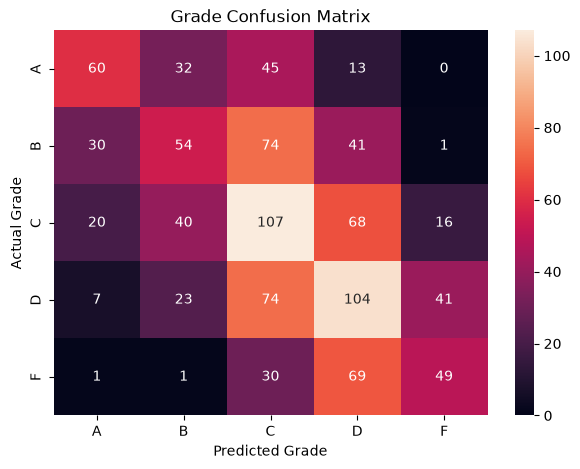


PASS / FAIL DISTRIBUTION
Result
Pass    4250
Fail     750
Name: count, dtype: int64

PASS / FAIL MODEL PERFORMANCE
Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

        Fail       0.35      0.71      0.47       150
        Pass       0.94      0.77      0.84       850

    accuracy                           0.76      1000
   macro avg       0.65      0.74      0.66      1000
weighted avg       0.85      0.76      0.79      1000


Confusion Matrix:
[[107  43]
 [197 653]]


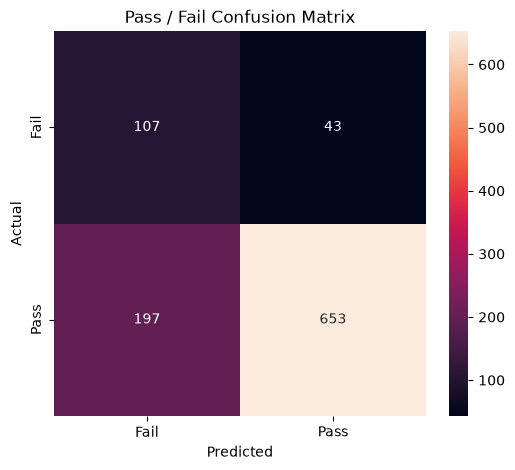


RISK THRESHOLDS
Fail below: 63.36
At Risk below: 66.66

RISK LEVEL DISTRIBUTION
Risk_Level
Safe       774
At Risk    156
Fail        70
Name: count, dtype: int64

NEW STUDENT FINAL PREDICTION
Predicted Total Score: 79.3
Predicted Grade: A
Pass / Fail: Pass
Risk Level: Safe


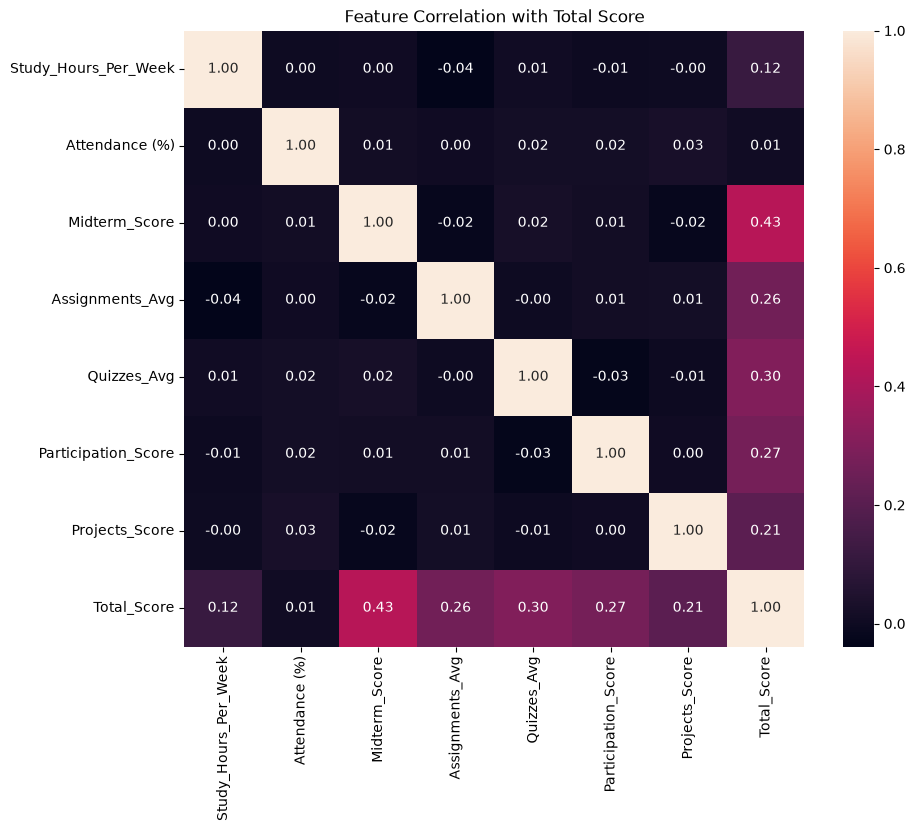

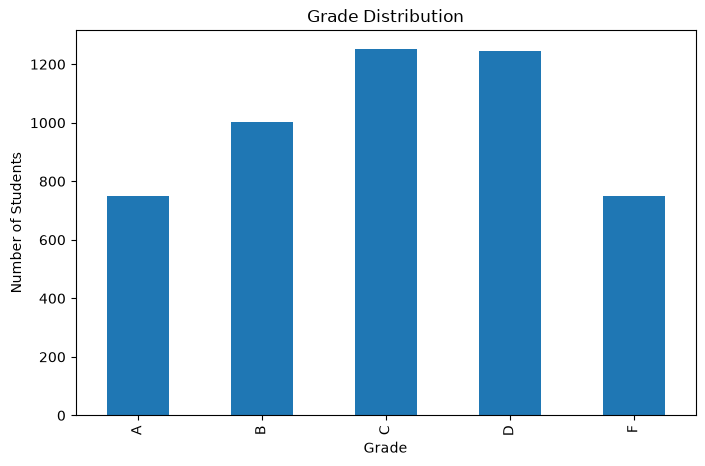

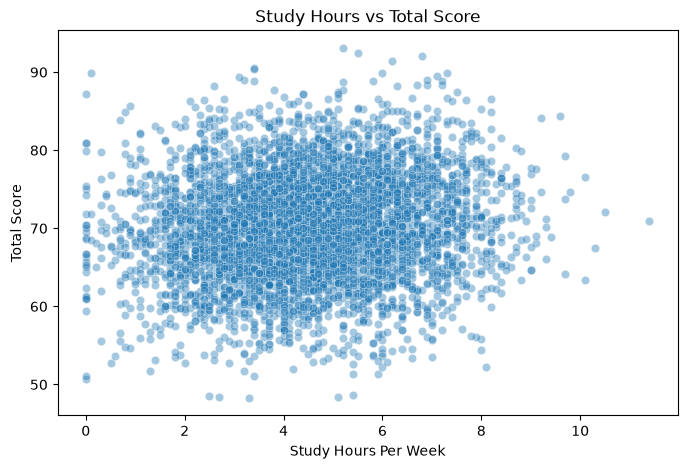

Regression model saved!
Grade model saved!
Pass/Fail model + scaler saved!

PROJECT COMPLETED


In [1]:
# ============================================================
# STUDENT PERFORMANCE ML PROJECT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

data = pd.read_csv("student_performance_grades_v4.csv")

print("Dataset Shape:", data.shape)

print("\nFirst 5 Rows:")
print(data.head())


# ============================================================
# 2. FEATURES
# ============================================================

features = [
    'Study_Hours_Per_Week',
    'Attendance (%)',
    'Midterm_Score',
    'Assignments_Avg',
    'Quizzes_Avg',
    'Participation_Score',
    'Projects_Score'
]

X = data[features]

y_score = data['Total_Score']


# ============================================================
# 3. SCORE PREDICTION
#    LINEAR REGRESSION
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_score,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)


# ============================================================
# 4. LINEAR REGRESSION PERFORMANCE
# ============================================================

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("\n============================================")
print("LINEAR REGRESSION PERFORMANCE")
print("============================================")

print("MAE :", round(linear_mae, 2))
print("MSE :", round(linear_mse, 2))
print("RMSE:", round(linear_rmse, 2))
print("R2 Score:", round(linear_r2, 4))


# ============================================================
# 5. MODEL COMPARISON
# ============================================================

tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=8
)

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=8
)

tree_model.fit(
    X_train,
    y_train
)

forest_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(
    X_test
)

forest_predictions = forest_model.predict(
    X_test
)


tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)


forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_predictions
    )
)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)


comparison = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        linear_mae,
        tree_mae,
        forest_mae
    ],

    'RMSE': [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],

    'R2 Score': [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})


print("\n============================================")
print("MODEL COMPARISON")
print("============================================")

print(
    comparison.round(4)
)


# ============================================================
# 6. FEATURE IMPACT
# ============================================================

feature_impact = pd.DataFrame({

    'Feature': features,

    'Coefficient': linear_model.coef_
})

feature_impact['Absolute_Impact'] = (
    feature_impact['Coefficient'].abs()
)

feature_impact = feature_impact.sort_values(
    'Absolute_Impact',
    ascending=False
)

print("\n============================================")
print("FEATURE IMPACT")
print("============================================")

print(
    feature_impact
)


# ============================================================
# 7. GRADE DISTRIBUTION
# ============================================================

print("\n============================================")
print("GRADE DISTRIBUTION")
print("============================================")

print(
    data['Grade'].value_counts()
)


# ============================================================
# 8. GRADE CLASSIFICATION
#    RANDOM FOREST + TUNING
# ============================================================

X_grade = data[features]

y_grade = data['Grade']


Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_grade,
    y_grade,
    test_size=0.2,
    random_state=42,
    stratify=y_grade
)


# ============================================================
# 9. RANDOM FOREST GRID SEARCH
# ============================================================

grade_rf = RandomForestClassifier(
    random_state=42
)

grade_parameters = {

    'n_estimators': [
        100,
        200
    ],

    'max_depth': [
        6,
        8,
        10
    ],

    'min_samples_split': [
        2,
        5
    ],

    'min_samples_leaf': [
        1,
        2,
        4
    ]
}


grade_grid = GridSearchCV(

    estimator=grade_rf,

    param_grid=grade_parameters,

    cv=3,

    scoring='accuracy',

    n_jobs=-1
)


grade_grid.fit(
    Xg_train,
    yg_train
)


# ============================================================
# 10. BEST GRADE MODEL
# ============================================================

best_grade_model = grade_grid.best_estimator_

grade_predictions = best_grade_model.predict(
    Xg_test
)

grade_accuracy = accuracy_score(
    yg_test,
    grade_predictions
)


print("\n============================================")
print("TUNED RANDOM FOREST - GRADE")
print("============================================")

print(
    "Best Parameters:"
)

print(
    grade_grid.best_params_
)

print(
    "Best CV Accuracy:",
    round(
        grade_grid.best_score_,
        4
    )
)

print(
    "Test Accuracy:",
    round(
        grade_accuracy,
        4
    )
)


# ============================================================
# 11. GRADE CLASSIFICATION REPORT
# ============================================================

print("\n============================================")
print("GRADE CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        yg_test,
        grade_predictions,
        zero_division=0
    )
)


# ============================================================
# 12. GRADE CONFUSION MATRIX
# ============================================================

grade_labels = [
    'A',
    'B',
    'C',
    'D',
    'F'
]

grade_cm = confusion_matrix(
    yg_test,
    grade_predictions,
    labels=grade_labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    grade_cm,
    annot=True,
    fmt='d',
    xticklabels=grade_labels,
    yticklabels=grade_labels
)

plt.xlabel("Predicted Grade")
plt.ylabel("Actual Grade")
plt.title("Grade Confusion Matrix")

plt.show()


# ============================================================
# 13. PASS / FAIL TARGET
# ============================================================

data['Result'] = data['Grade'].apply(

    lambda grade:
    'Fail'
    if grade == 'F'
    else 'Pass'
)


print("\n============================================")
print("PASS / FAIL DISTRIBUTION")
print("============================================")

print(
    data['Result'].value_counts()
)


# ============================================================
# 14. PASS / FAIL DATA
# ============================================================

X_result = data[features]

y_result = data['Result']


Xr_train, Xr_test, yr_train, yr_test = train_test_split(

    X_result,

    y_result,

    test_size=0.2,

    random_state=42,

    stratify=y_result
)


# ============================================================
# 15. SCALE DATA
# ============================================================

scaler = StandardScaler()

Xr_train_scaled = scaler.fit_transform(
    Xr_train
)

Xr_test_scaled = scaler.transform(
    Xr_test
)


# ============================================================
# 16. LOGISTIC REGRESSION
#    BALANCED WEIGHTS
# ============================================================

result_model = LogisticRegression(

    max_iter=2000,

    class_weight='balanced'
)


result_model.fit(

    Xr_train_scaled,

    yr_train
)


# ============================================================
# 17. PASS / FAIL PREDICTION
# ============================================================

result_predictions = result_model.predict(

    Xr_test_scaled
)


# ============================================================
# 18. PASS / FAIL PERFORMANCE
# ============================================================

result_accuracy = accuracy_score(

    yr_test,

    result_predictions
)


print("\n============================================")
print("PASS / FAIL MODEL PERFORMANCE")
print("============================================")

print(

    "Accuracy:",

    round(
        result_accuracy,
        4
    )
)


print("\nClassification Report:")

print(

    classification_report(

        yr_test,

        result_predictions,

        zero_division=0
    )
)


# ============================================================
# 19. PASS / FAIL CONFUSION MATRIX
# ============================================================

result_cm = confusion_matrix(

    yr_test,

    result_predictions,

    labels=[
        'Fail',
        'Pass'
    ]
)


print("\nConfusion Matrix:")

print(
    result_cm
)


plt.figure(figsize=(6, 5))

sns.heatmap(

    result_cm,

    annot=True,

    fmt='d',

    xticklabels=[
        'Fail',
        'Pass'
    ],

    yticklabels=[
        'Fail',
        'Pass'
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Pass / Fail Confusion Matrix"
)

plt.show()


# ============================================================
# 20. RISK THRESHOLDS
# ============================================================

fail_threshold = data[
    'Total_Score'
].quantile(
    0.15
)

risk_threshold = data[
    'Total_Score'
].quantile(
    0.30
)


print("\n============================================")
print("RISK THRESHOLDS")
print("============================================")

print(
    "Fail below:",
    round(
        fail_threshold,
        2
    )
)

print(
    "At Risk below:",
    round(
        risk_threshold,
        2
    )
)


# ============================================================
# 21. RISK FUNCTION
# ============================================================

def check_risk(score):

    if score < fail_threshold:

        return "Fail"

    elif score < risk_threshold:

        return "At Risk"

    else:

        return "Safe"


# ============================================================
# 22. RISK ANALYSIS
# ============================================================

risk_labels = [

    check_risk(score)

    for score in linear_predictions
]


risk_results = pd.DataFrame({

    'Actual_Total_Score':
    y_test.values,

    'Predicted_Total_Score':
    linear_predictions,

    'Risk_Level':
    risk_labels

})


print("\n============================================")
print("RISK LEVEL DISTRIBUTION")
print("============================================")

print(

    risk_results[
        'Risk_Level'
    ].value_counts()
)


# ============================================================
# 23. NEW STUDENT
# ============================================================

new_student = pd.DataFrame({

    'Study_Hours_Per_Week': [9],

    'Attendance (%)': [90],

    'Midterm_Score': [80],

    'Assignments_Avg': [85],

    'Quizzes_Avg': [78],

    'Participation_Score': [70],

    'Projects_Score': [88]

})


# ============================================================
# 24. NEW STUDENT SCORE
# ============================================================

new_score = linear_model.predict(

    new_student
)[0]


# ============================================================
# 25. NEW STUDENT GRADE
# ============================================================

new_grade = best_grade_model.predict(

    new_student
)[0]


# ============================================================
# 26. NEW STUDENT PASS / FAIL
# ============================================================

new_result = result_model.predict(

    scaler.transform(
        new_student
    )
)[0]


# ============================================================
# 27. NEW STUDENT RISK
# ============================================================

new_risk = check_risk(

    new_score
)


# ============================================================
# 28. FINAL NEW STUDENT PREDICTION
# ============================================================

print("\n============================================")
print("NEW STUDENT FINAL PREDICTION")
print("============================================")

print(

    "Predicted Total Score:",

    round(
        new_score,
        2
    )
)

print(

    "Predicted Grade:",

    new_grade
)

print(

    "Pass / Fail:",

    new_result
)

print(

    "Risk Level:",

    new_risk
)


# ============================================================
# 29. CORRELATION HEATMAP
# ============================================================

plt.figure(
    figsize=(10, 8)
)

correlation_matrix = data[
    features + [
        'Total_Score'
    ]
].corr()


sns.heatmap(

    correlation_matrix,

    annot=True,

    fmt='.2f'
)


plt.title(
    "Feature Correlation with Total Score"
)

plt.show()


# ============================================================
# 30. GRADE DISTRIBUTION GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)

data[
    'Grade'
].value_counts().sort_index().plot(
    kind='bar'
)

plt.xlabel(
    "Grade"
)

plt.ylabel(
    "Number of Students"
)

plt.title(
    "Grade Distribution"
)

plt.show()


# ============================================================
# 31. STUDY HOURS VS TOTAL SCORE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.scatterplot(

    data=data,

    x='Study_Hours_Per_Week',

    y='Total_Score',

    alpha=0.4
)

plt.xlabel(
    "Study Hours Per Week"
)

plt.ylabel(
    "Total Score"
)

plt.title(
    "Study Hours vs Total Score"
)

plt.show()


# ============================================================
# 32. SAVE ALL MODELS AND SCALER
# ============================================================
# NOTE: variable names below match what was actually created
# above in this file:
#   - linear_model      (Section 3)  -> Total_Score regression
#   - best_grade_model  (Section 10) -> Grade classifier (Random Forest, no scaler needed)
#   - result_model      (Section 16) -> Pass/Fail classifier
#   - scaler            (Section 15) -> scaler used only by result_model

import joblib

# 1. Regression Model (Total_Score)
joblib.dump(linear_model, 'student_score_model.pkl')
print("Regression model saved!")

# 2. Grade Classification Model (Random Forest - tree models don't need scaling)
joblib.dump(best_grade_model, 'student_grade_model.pkl')
print("Grade model saved!")

# 3. Pass/Fail Classification Model + its scaler
joblib.dump(result_model, 'student_result_model.pkl')
joblib.dump(scaler, 'student_result_scaler.pkl')
print("Pass/Fail model + scaler saved!")


# ============================================================
# PROJECT COMPLETE
# ============================================================

print("\n============================================")
print("PROJECT COMPLETED")
print("============================================")